# Análisis Comparativo: Redes Feedforward vs. RNN

**Componente Autónomo – Machine Learning 2 | Unidad 3, Tema 1**  
**Estudiante:** Rubén Casamín  
**Fecha:** 12 de junio de 2026

---

Este notebook implementa:
1. **Diagrama de arquitectura RNN** desplegada en el tiempo.
2. **Modelo Feedforward (MLP)** para predicción de series de tiempo.
3. **Modelo RNN Vanilla** para la misma tarea.
4. **Comparación visual** de ambos modelos.
5. **Diagrama del flujo de datos** en la RNN.

## 1. Importación de librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo para gráficos
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight'
})

# Fijar semilla para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

Dispositivo: cuda


## 2. Diagrama de Arquitectura RNN

A continuación se genera un diagrama conceptual de la RNN simple tanto en su forma **plegada** (compacta) como **desplegada** en el tiempo.

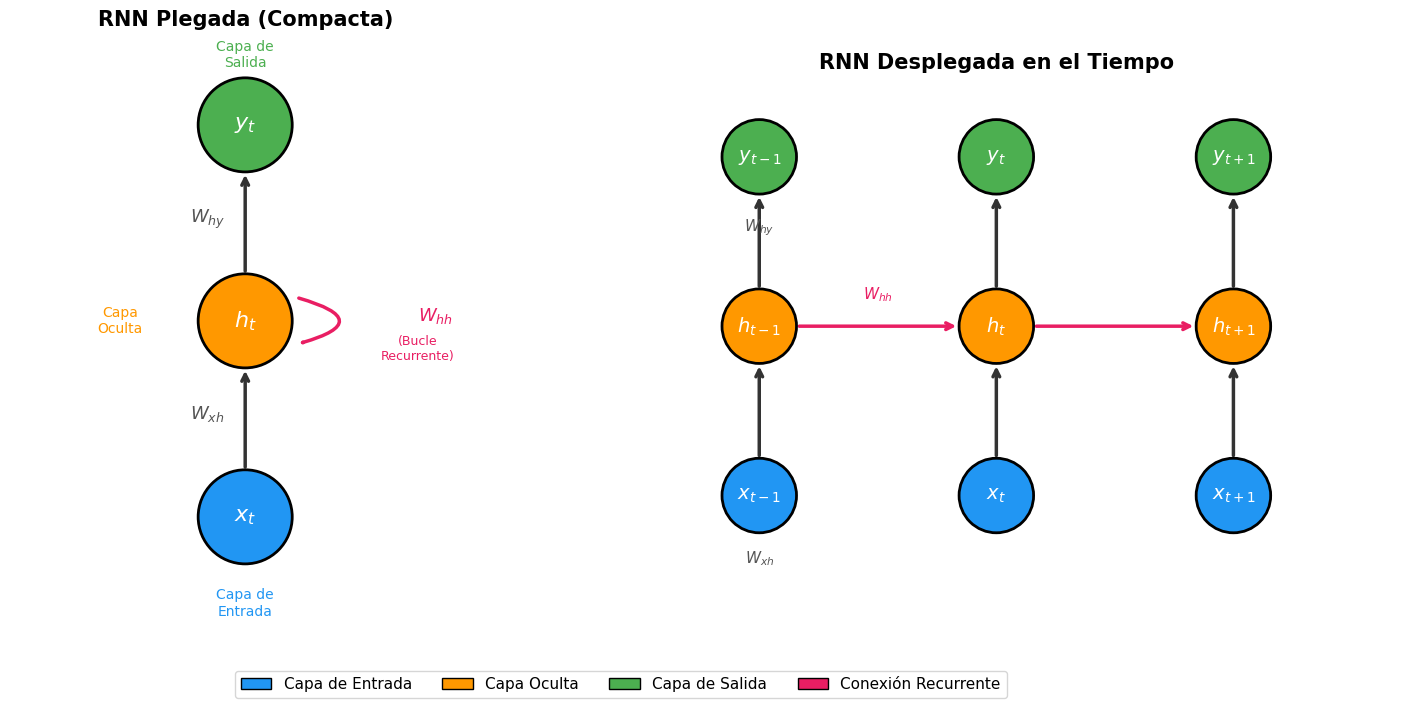

Figura guardada: fig1_arquitectura_rnn.png


In [2]:
def draw_rnn_architecture():
    """
    Dibuja la arquitectura de una RNN simple:
    - Panel izquierdo: forma compacta (plegada) con bucle recurrente.
    - Panel derecho: forma desplegada en el tiempo (3 pasos temporales).
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # ════════════════════════════════════════════════════
    # Panel izquierdo: RNN Plegada (Compacta)
    # ════════════════════════════════════════════════════
    ax1.set_xlim(-2, 4)
    ax1.set_ylim(-1, 7)
    ax1.set_aspect('equal')
    ax1.axis('off')
    ax1.set_title('RNN Plegada (Compacta)', fontsize=15, fontweight='bold', pad=15)

    # Colores
    color_input = '#2196F3'    # Azul
    color_hidden = '#FF9800'   # Naranja
    color_output = '#4CAF50'   # Verde

    # Nodos
    circle_r = 0.6
    # Entrada
    input_circle = plt.Circle((1, 1), circle_r, color=color_input, ec='black', lw=2, zorder=5)
    ax1.add_patch(input_circle)
    ax1.text(1, 1, '$x_t$', ha='center', va='center', fontsize=16, fontweight='bold', color='white', zorder=6)
    ax1.text(1, -0.1, 'Capa de\nEntrada', ha='center', va='center', fontsize=10, color=color_input)

    # Oculta
    hidden_circle = plt.Circle((1, 3.5), circle_r, color=color_hidden, ec='black', lw=2, zorder=5)
    ax1.add_patch(hidden_circle)
    ax1.text(1, 3.5, '$h_t$', ha='center', va='center', fontsize=16, fontweight='bold', color='white', zorder=6)
    ax1.text(-0.6, 3.5, 'Capa\nOculta', ha='center', va='center', fontsize=10, color=color_hidden)

    # Salida
    output_circle = plt.Circle((1, 6), circle_r, color=color_output, ec='black', lw=2, zorder=5)
    ax1.add_patch(output_circle)
    ax1.text(1, 6, '$y_t$', ha='center', va='center', fontsize=16, fontweight='bold', color='white', zorder=6)
    ax1.text(1, 6.9, 'Capa de\nSalida', ha='center', va='center', fontsize=10, color=color_output)

    # Flechas
    arrow_props = dict(arrowstyle='->', lw=2.5, color='#333333')
    # Entrada -> Oculta
    ax1.annotate('', xy=(1, 3.5 - circle_r), xytext=(1, 1 + circle_r), arrowprops=arrow_props)
    ax1.text(0.3, 2.25, '$W_{xh}$', fontsize=13, fontstyle='italic', color='#555')

    # Oculta -> Salida
    ax1.annotate('', xy=(1, 6 - circle_r), xytext=(1, 3.5 + circle_r), arrowprops=arrow_props)
    ax1.text(0.3, 4.75, '$W_{hy}$', fontsize=13, fontstyle='italic', color='#555')

    # Bucle recurrente
    from matplotlib.patches import FancyArrowPatch
    arc = mpatches.FancyArrowPatch(
        (1 + circle_r + 0.05, 3.8),
        (1 + circle_r + 0.05, 3.2),
        connectionstyle='arc3,rad=-1.8',
        arrowstyle='->', lw=2.5, color='#E91E63', zorder=4
    )
    ax1.add_patch(arc)
    ax1.text(3.2, 3.5, '$W_{hh}$', fontsize=13, fontstyle='italic', color='#E91E63')
    ax1.text(3.2, 3.0, '(Bucle\nRecurrente)', fontsize=9, ha='center', color='#E91E63')

    # ════════════════════════════════════════════════════
    # Panel derecho: RNN Desplegada en el Tiempo
    # ════════════════════════════════════════════════════
    ax2.set_xlim(-1, 11)
    ax2.set_ylim(-1, 7)
    ax2.set_aspect('equal')
    ax2.axis('off')
    ax2.set_title('RNN Desplegada en el Tiempo', fontsize=15, fontweight='bold', pad=15)

    time_steps = 3
    spacing = 3.5
    r = 0.55

    labels_t = ['t-1', 't', 't+1']

    for i in range(time_steps):
        cx = 1.5 + i * spacing

        # Entrada
        inp = plt.Circle((cx, 1), r, color=color_input, ec='black', lw=2, zorder=5)
        ax2.add_patch(inp)
        ax2.text(cx, 1, f'$x_{{{labels_t[i]}}}$', ha='center', va='center', fontsize=14, fontweight='bold', color='white', zorder=6)

        # Oculta
        hid = plt.Circle((cx, 3.5), r, color=color_hidden, ec='black', lw=2, zorder=5)
        ax2.add_patch(hid)
        ax2.text(cx, 3.5, f'$h_{{{labels_t[i]}}}$', ha='center', va='center', fontsize=14, fontweight='bold', color='white', zorder=6)

        # Salida
        out = plt.Circle((cx, 6), r, color=color_output, ec='black', lw=2, zorder=5)
        ax2.add_patch(out)
        ax2.text(cx, 6, f'$y_{{{labels_t[i]}}}$', ha='center', va='center', fontsize=14, fontweight='bold', color='white', zorder=6)

        # Flecha: Entrada -> Oculta
        ax2.annotate('', xy=(cx, 3.5 - r), xytext=(cx, 1 + r), arrowprops=arrow_props)

        # Flecha: Oculta -> Salida
        ax2.annotate('', xy=(cx, 6 - r), xytext=(cx, 3.5 + r), arrowprops=arrow_props)

        # Flecha: Recurrencia (oculta -> siguiente oculta)
        if i < time_steps - 1:
            cx_next = cx + spacing
            ax2.annotate('', xy=(cx_next - r, 3.5), xytext=(cx + r, 3.5),
                        arrowprops=dict(arrowstyle='->', lw=2.5, color='#E91E63'))

    # Etiquetas de pesos
    ax2.text(1.5, 0.0, '$W_{xh}$', fontsize=11, fontstyle='italic', color='#555', ha='center')
    ax2.text(1.5, 4.9, '$W_{hy}$', fontsize=11, fontstyle='italic', color='#555', ha='center')
    ax2.text(3.25, 3.9, '$W_{hh}$', fontsize=11, fontstyle='italic', color='#E91E63', ha='center')

    # Leyenda
    legend_elements = [
        mpatches.Patch(facecolor=color_input, edgecolor='black', label='Capa de Entrada'),
        mpatches.Patch(facecolor=color_hidden, edgecolor='black', label='Capa Oculta'),
        mpatches.Patch(facecolor=color_output, edgecolor='black', label='Capa de Salida'),
        mpatches.Patch(facecolor='#E91E63', edgecolor='black', label='Conexión Recurrente'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=11, frameon=True,
              bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.savefig('fig1_arquitectura_rnn.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print('Figura guardada: fig1_arquitectura_rnn.png')

draw_rnn_architecture()

## 3. Generación de Datos: Serie de Tiempo Sinusoidal

Generamos una señal sinusoidal con ruido: $y(t) = \sin(0.1 \cdot t) + \varepsilon$, donde $\varepsilon \sim \mathcal{N}(0, 0.05)$.

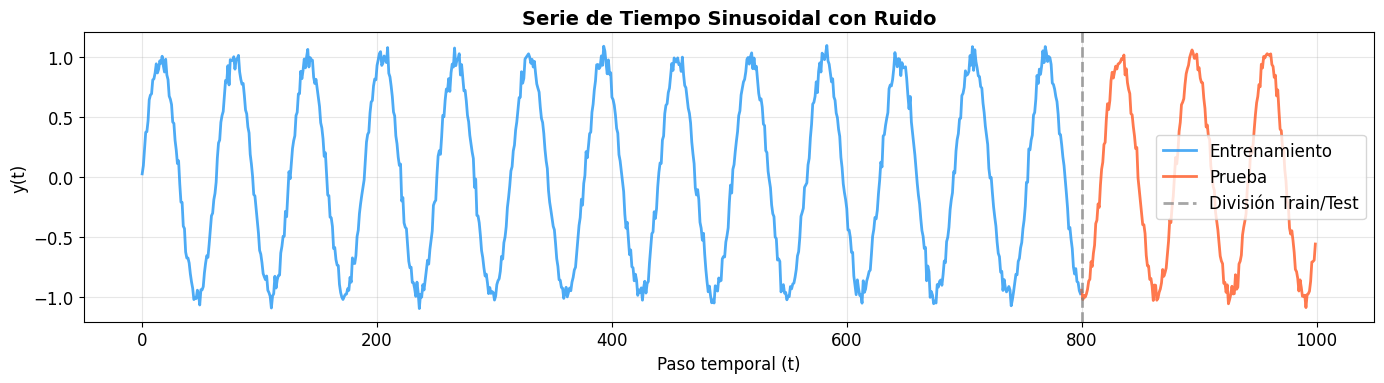

Total de datos: 1000, Entrenamiento: 800, Prueba: 200


In [3]:
# ──── Parámetros del dataset ────
N = 1000                 # Número total de puntos
LOOKBACK = 20            # Ventana de observaciones pasadas
TRAIN_RATIO = 0.8        # 80% entrenamiento, 20% prueba

# Generar señal sinusoidal con ruido
t = np.arange(N)
y = np.sin(0.1 * t) + np.random.normal(0, 0.05, N)

# Visualizar la serie de tiempo
fig, ax = plt.subplots(figsize=(14, 4))
split_idx = int(N * TRAIN_RATIO)
ax.plot(t[:split_idx], y[:split_idx], color='#2196F3', alpha=0.8, label='Entrenamiento')
ax.plot(t[split_idx:], y[split_idx:], color='#FF5722', alpha=0.8, label='Prueba')
ax.axvline(x=split_idx, color='gray', linestyle='--', alpha=0.7, label='División Train/Test')
ax.set_xlabel('Paso temporal (t)')
ax.set_ylabel('y(t)')
ax.set_title('Serie de Tiempo Sinusoidal con Ruido', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_serie_tiempo.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Total de datos: {N}, Entrenamiento: {split_idx}, Prueba: {N - split_idx}')

In [4]:
def create_sequences(data, lookback):
    """Crea secuencias de entrada-salida para el entrenamiento.

    Args:
        data: array con la serie de tiempo.
        lookback: número de pasos pasados a usar como entrada.

    Returns:
        X: tensor de secuencias de entrada (num_samples, lookback).
        Y: tensor de valores objetivo (num_samples, 1).
    """
    X, Y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])
        Y.append(data[i + lookback])
    return np.array(X), np.array(Y)

# Crear secuencias
X, Y = create_sequences(y, LOOKBACK)

# Dividir en entrenamiento y prueba
split = int(len(X) * TRAIN_RATIO)
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

# Convertir a tensores de PyTorch
X_train_t = torch.FloatTensor(X_train).to(device)
Y_train_t = torch.FloatTensor(Y_train).reshape(-1, 1).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
Y_test_t  = torch.FloatTensor(Y_test).reshape(-1, 1).to(device)

# DataLoader
BATCH_SIZE = 32
train_dataset = TensorDataset(X_train_t, Y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f'Forma de X_train: {X_train_t.shape}')
print(f'Forma de Y_train: {Y_train_t.shape}')
print(f'Forma de X_test:  {X_test_t.shape}')
print(f'Forma de Y_test:  {Y_test_t.shape}')

Forma de X_train: torch.Size([784, 20])
Forma de Y_train: torch.Size([784, 1])
Forma de X_test:  torch.Size([196, 20])
Forma de Y_test:  torch.Size([196, 1])


## 4. Definición de Modelos

### 4.1 Modelo Feedforward (MLP)
Procesa la ventana de observaciones como un vector plano, sin considerar el orden temporal.

In [5]:
class FeedforwardModel(nn.Module):
    """Red Neuronal Feedforward (MLP) para predicción de series de tiempo.

    Procesa toda la ventana temporal como un vector de entrada plano,
    sin modelar explícitamente dependencias secuenciales.

    Arquitectura:
        Entrada (lookback) → FC(64) → ReLU → FC(32) → ReLU → FC(1)
    """
    def __init__(self, input_size, hidden1=64, hidden2=32):
        super(FeedforwardModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        # x shape: (batch, lookback)
        return self.network(x)

print('Modelo Feedforward (MLP):')
mlp_model = FeedforwardModel(LOOKBACK).to(device)
print(mlp_model)
total_params_mlp = sum(p.numel() for p in mlp_model.parameters())
print(f'Total de parámetros: {total_params_mlp:,}')

Modelo Feedforward (MLP):
FeedforwardModel(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total de parámetros: 3,457


### 4.2 Modelo RNN Vanilla
Procesa la secuencia paso a paso, manteniendo un estado oculto recurrente.

**Ecuación del estado oculto:**
$$h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b_h)$$

**Ecuación de la salida:**
$$y_t = W_{hy} \cdot h_t + b_y$$

In [6]:
class VanillaRNN(nn.Module):
    """Red Neuronal Recurrente (RNN) Vanilla para predicción de series de tiempo.

    Procesa la secuencia paso a paso, actualizando el estado oculto
    en cada paso temporal mediante la ecuación:
        h_t = tanh(W_xh * x_t + W_hh * h_{t-1} + b_h)

    Arquitectura:
        Entrada (seq_len, 1) → RNN(hidden=32) → FC(1)
    """
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(VanillaRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Capa RNN: implementa h_t = tanh(W_xh * x_t + W_hh * h_{t-1} + b_h)
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh'
        )

        # Capa de salida: y_t = W_hy * h_t + b_y
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len) → necesitamos (batch, seq_len, input_size=1)
        x = x.unsqueeze(-1)

        # Inicializar estado oculto h_0
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward pass: procesar toda la secuencia
        # output: (batch, seq_len, hidden_size) - estados ocultos de todos los pasos
        # hn: (num_layers, batch, hidden_size) - último estado oculto
        output, hn = self.rnn(x, h0)

        # Usar el último estado oculto para la predicción
        last_hidden = output[:, -1, :]  # (batch, hidden_size)
        prediction = self.fc(last_hidden)  # (batch, 1)

        return prediction

print('Modelo RNN Vanilla:')
rnn_model = VanillaRNN(input_size=1, hidden_size=32).to(device)
print(rnn_model)
total_params_rnn = sum(p.numel() for p in rnn_model.parameters())
print(f'Total de parámetros: {total_params_rnn:,}')

Modelo RNN Vanilla:
VanillaRNN(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Total de parámetros: 1,153


## 5. Entrenamiento de Modelos

In [7]:
def train_model(model, train_loader, X_test, Y_test, epochs=100, lr=0.001, model_name='Modelo'):
    """Entrena un modelo y registra las pérdidas de entrenamiento y prueba.

    Args:
        model: modelo de PyTorch.
        train_loader: DataLoader de entrenamiento.
        X_test: tensor de entrada de prueba.
        Y_test: tensor de objetivo de prueba.
        epochs: número de épocas.
        lr: learning rate.
        model_name: nombre del modelo para logs.

    Returns:
        train_losses: lista de pérdidas de entrenamiento por época.
        test_losses: lista de pérdidas de prueba por época.
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0

        for batch_X, batch_Y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_Y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1

        avg_train_loss = epoch_loss / n_batches
        train_losses.append(avg_train_loss)

        # Evaluación en test
        model.eval()
        with torch.no_grad():
            test_pred = model(X_test)
            test_loss = criterion(test_pred, Y_test).item()
            test_losses.append(test_loss)

        if (epoch + 1) % 20 == 0:
            print(f'  [{model_name}] Época {epoch+1:3d}/{epochs} | '
                  f'Train Loss: {avg_train_loss:.6f} | Test Loss: {test_loss:.6f}')

    return train_losses, test_losses

EPOCHS = 100
LR = 0.001

print('='*60)
print('Entrenando Modelo Feedforward (MLP)...')
print('='*60)
mlp_train_losses, mlp_test_losses = train_model(
    mlp_model, train_loader, X_test_t, Y_test_t,
    epochs=EPOCHS, lr=LR, model_name='MLP'
)

print()
print('='*60)
print('Entrenando Modelo RNN Vanilla...')
print('='*60)
rnn_train_losses, rnn_test_losses = train_model(
    rnn_model, train_loader, X_test_t, Y_test_t,
    epochs=EPOCHS, lr=LR, model_name='RNN'
)

Entrenando Modelo Feedforward (MLP)...
  [MLP] Época  20/100 | Train Loss: 0.003002 | Test Loss: 0.002611
  [MLP] Época  40/100 | Train Loss: 0.002921 | Test Loss: 0.003170
  [MLP] Época  60/100 | Train Loss: 0.002696 | Test Loss: 0.002630
  [MLP] Época  80/100 | Train Loss: 0.002823 | Test Loss: 0.002863
  [MLP] Época 100/100 | Train Loss: 0.002799 | Test Loss: 0.003065

Entrenando Modelo RNN Vanilla...
  [RNN] Época  20/100 | Train Loss: 0.003343 | Test Loss: 0.002915
  [RNN] Época  40/100 | Train Loss: 0.003176 | Test Loss: 0.002889
  [RNN] Época  60/100 | Train Loss: 0.003363 | Test Loss: 0.002782
  [RNN] Época  80/100 | Train Loss: 0.003100 | Test Loss: 0.002996
  [RNN] Época 100/100 | Train Loss: 0.003077 | Test Loss: 0.002777


## 6. Visualización de Resultados

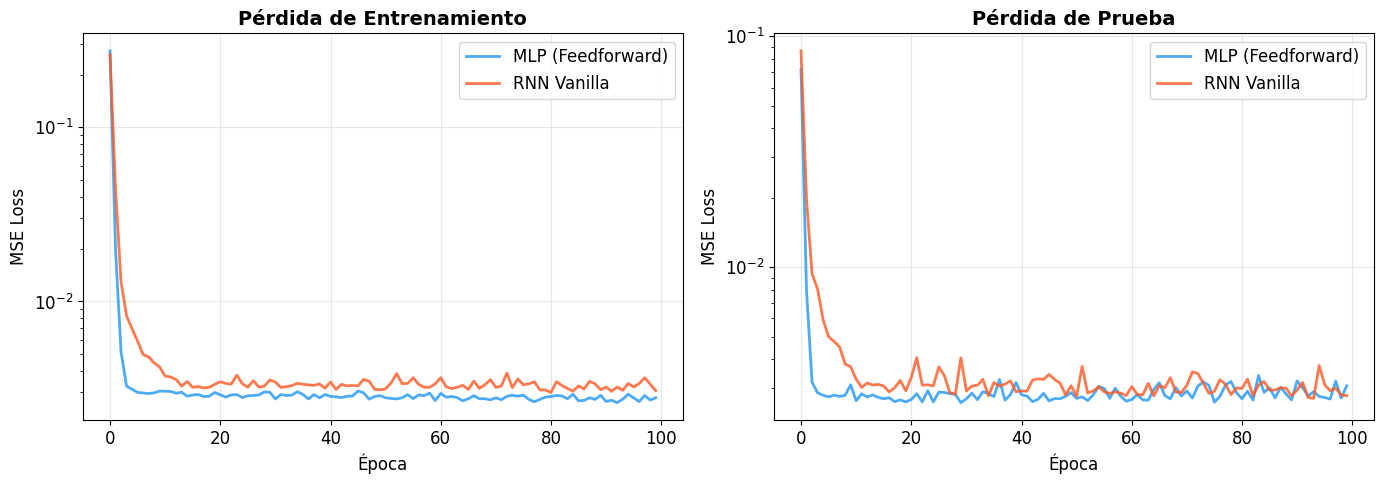

In [8]:
# ──── Curvas de pérdida ────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida de entrenamiento
ax1.plot(mlp_train_losses, color='#2196F3', alpha=0.8, label='MLP (Feedforward)')
ax1.plot(rnn_train_losses, color='#FF5722', alpha=0.8, label='RNN Vanilla')
ax1.set_xlabel('Época')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Pérdida de Entrenamiento', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Pérdida de prueba
ax2.plot(mlp_test_losses, color='#2196F3', alpha=0.8, label='MLP (Feedforward)')
ax2.plot(rnn_test_losses, color='#FF5722', alpha=0.8, label='RNN Vanilla')
ax2.set_xlabel('Época')
ax2.set_ylabel('MSE Loss')
ax2.set_title('Pérdida de Prueba', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig('fig3_curvas_perdida.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

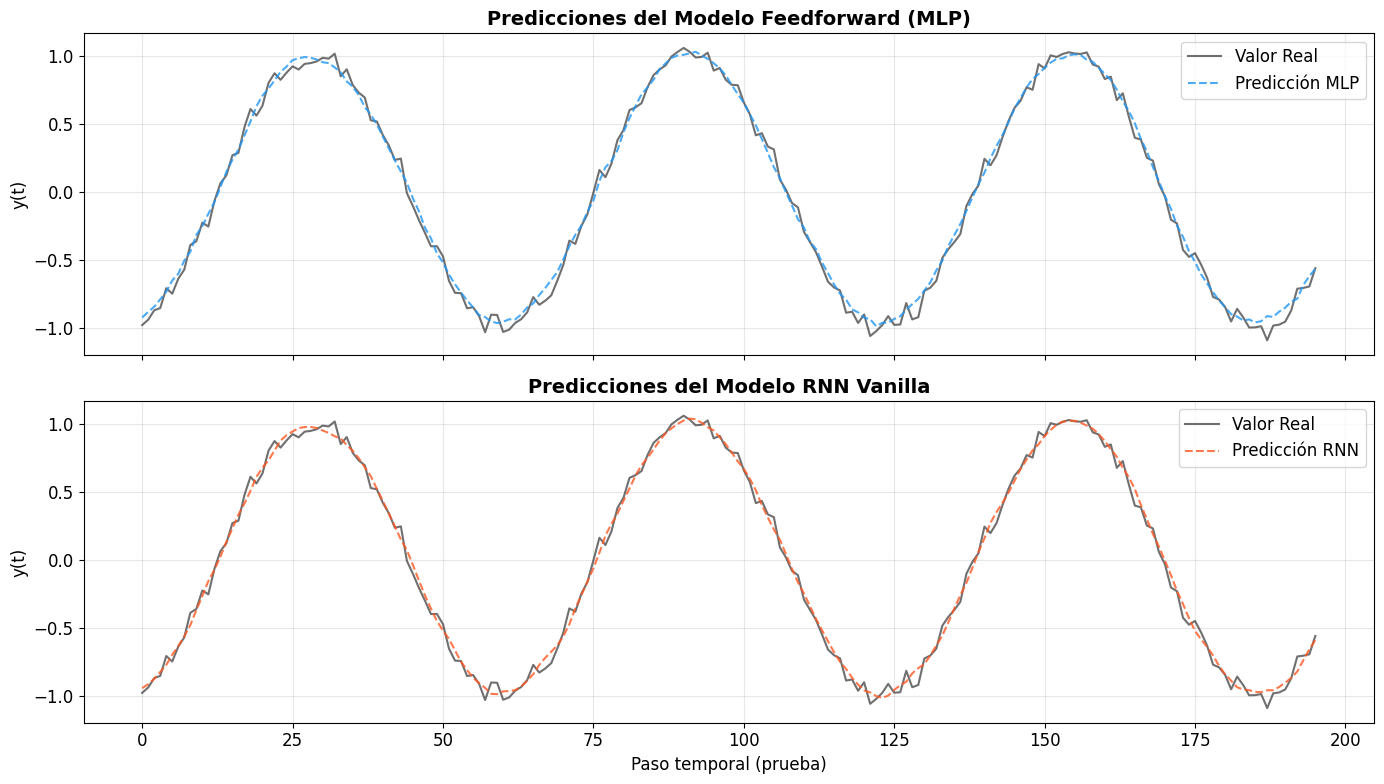

In [9]:
# ──── Predicciones sobre datos de prueba ────
mlp_model.eval()
rnn_model.eval()

with torch.no_grad():
    mlp_preds = mlp_model(X_test_t).cpu().numpy().flatten()
    rnn_preds = rnn_model(X_test_t).cpu().numpy().flatten()

y_true = Y_test

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Predicciones del MLP
axes[0].plot(y_true, color='#333333', alpha=0.7, label='Valor Real', linewidth=1.5)
axes[0].plot(mlp_preds, color='#2196F3', alpha=0.8, label='Predicción MLP', linewidth=1.5, linestyle='--')
axes[0].set_ylabel('y(t)')
axes[0].set_title('Predicciones del Modelo Feedforward (MLP)', fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Predicciones de la RNN
axes[1].plot(y_true, color='#333333', alpha=0.7, label='Valor Real', linewidth=1.5)
axes[1].plot(rnn_preds, color='#FF5722', alpha=0.8, label='Predicción RNN', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Paso temporal (prueba)')
axes[1].set_ylabel('y(t)')
axes[1].set_title('Predicciones del Modelo RNN Vanilla', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_predicciones_comparativas.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

┌────────────────────────────────────────────┐
│   MÉTRICAS COMPARATIVAS (Datos de Prueba)  │
├──────────────┬──────────────┬──────────────┤
│    Métrica   │     MLP      │   RNN Vanilla│
├──────────────┼──────────────┼──────────────┤
│     MSE      │   0.003065   │   0.002777   │
│     MAE      │   0.045381   │   0.042841   │
└──────────────┴──────────────┴──────────────┘


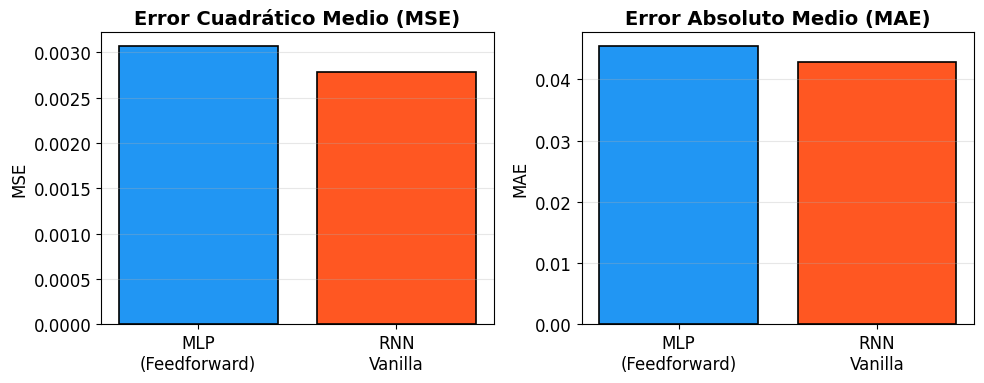

In [10]:
# ──── Métricas comparativas ────
from sklearn.metrics import mean_squared_error, mean_absolute_error

mlp_mse = mean_squared_error(y_true, mlp_preds)
rnn_mse = mean_squared_error(y_true, rnn_preds)
mlp_mae = mean_absolute_error(y_true, mlp_preds)
rnn_mae = mean_absolute_error(y_true, rnn_preds)

print('┌────────────────────────────────────────────┐')
print('│   MÉTRICAS COMPARATIVAS (Datos de Prueba)  │')
print('├──────────────┬──────────────┬──────────────┤')
print('│    Métrica   │     MLP      │   RNN Vanilla│')
print('├──────────────┼──────────────┼──────────────┤')
print(f'│     MSE      │   {mlp_mse:.6f}   │   {rnn_mse:.6f}   │')
print(f'│     MAE      │   {mlp_mae:.6f}   │   {rnn_mae:.6f}   │')
print('└──────────────┴──────────────┴──────────────┘')

# Gráfico de barras comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

models = ['MLP\n(Feedforward)', 'RNN\nVanilla']
colors = ['#2196F3', '#FF5722']

ax1.bar(models, [mlp_mse, rnn_mse], color=colors, edgecolor='black', linewidth=1.2)
ax1.set_ylabel('MSE')
ax1.set_title('Error Cuadrático Medio (MSE)', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

ax2.bar(models, [mlp_mae, rnn_mae], color=colors, edgecolor='black', linewidth=1.2)
ax2.set_ylabel('MAE')
ax2.set_title('Error Absoluto Medio (MAE)', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_metricas_comparativas.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 7. Diagrama del Flujo de Datos en la RNN

El siguiente diagrama muestra cómo fluyen los datos a través de la RNN en la tarea de predicción de series de tiempo.

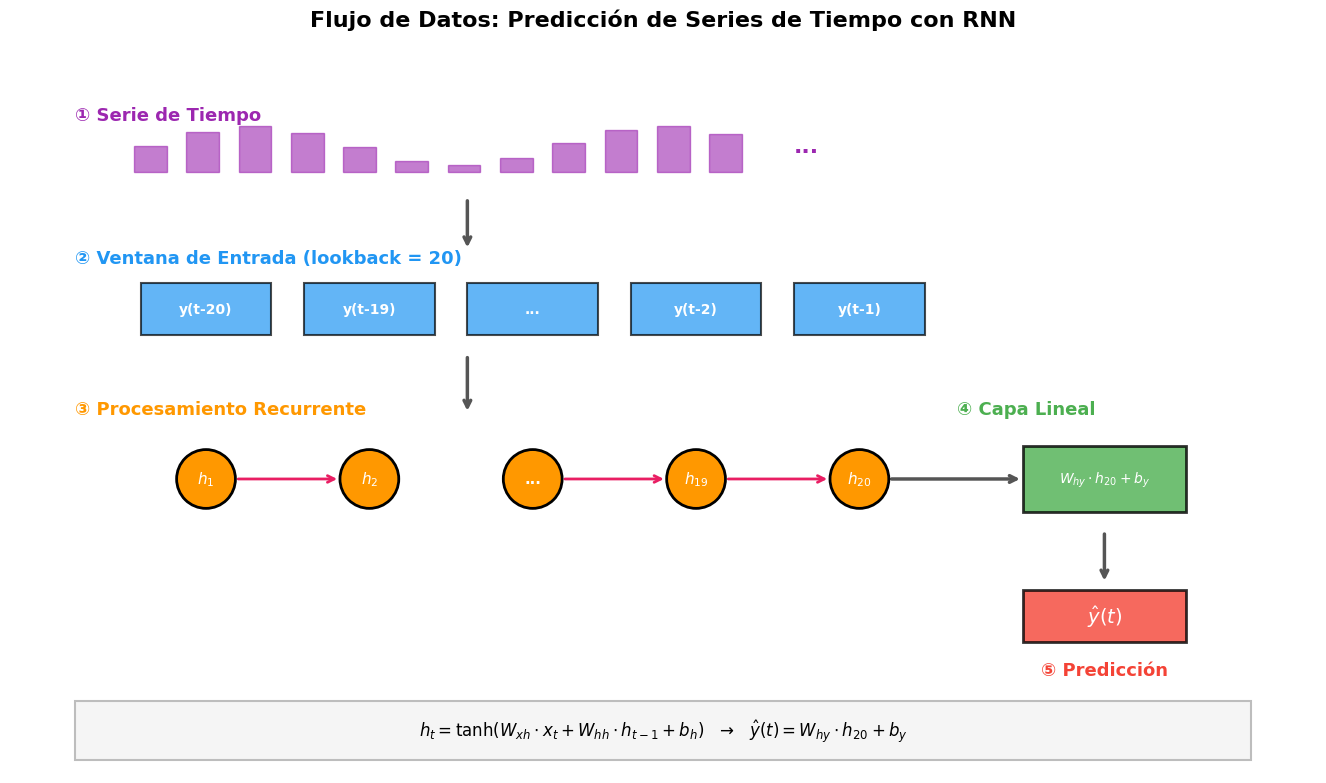

Figura guardada: fig6_flujo_datos_rnn.png


In [11]:
def draw_data_flow_diagram():
    """
    Diagrama del flujo de datos de la RNN para predicción de series de tiempo.
    Muestra cómo la ventana de 20 pasos se procesa secuencialmente.
    """
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_xlim(-2, 18)
    ax.set_ylim(-2, 9)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Flujo de Datos: Predicción de Series de Tiempo con RNN',
                 fontsize=16, fontweight='bold', pad=20)

    # Colores
    c_data = '#9C27B0'   # Púrpura
    c_input = '#2196F3'  # Azul
    c_hidden = '#FF9800' # Naranja
    c_output = '#4CAF50' # Verde
    c_pred = '#F44336'   # Rojo

    # ── Paso 1: Serie de tiempo original ──
    ax.text(-1, 8, '① Serie de Tiempo', fontsize=13, fontweight='bold', color=c_data)
    for i in range(12):
        x_pos = i * 0.8
        h = 0.3 * np.sin(0.8 * i) + 0.4
        rect = plt.Rectangle((x_pos - 0.1, 7.2), 0.5, h, color=c_data, alpha=0.6)
        ax.add_patch(rect)
    ax.text(10, 7.5, '...', fontsize=16, fontweight='bold', color=c_data)

    # Flecha hacia abajo
    ax.annotate('', xy=(5, 6.0), xytext=(5, 6.8),
               arrowprops=dict(arrowstyle='->', lw=2.5, color='#555'))

    # ── Paso 2: Ventana de entrada ──
    ax.text(-1, 5.8, '② Ventana de Entrada (lookback = 20)', fontsize=13,
            fontweight='bold', color=c_input)
    window_labels = ['y(t-20)', 'y(t-19)', '...', 'y(t-2)', 'y(t-1)']
    positions = [0, 2.5, 5, 7.5, 10]
    for i, (pos, label) in enumerate(zip(positions, window_labels)):
        rect = plt.Rectangle((pos, 4.7), 2, 0.8, color=c_input, alpha=0.7,
                            ec='black', lw=1.5, zorder=5)
        ax.add_patch(rect)
        ax.text(pos + 1, 5.1, label, ha='center', va='center',
               fontsize=10, fontweight='bold', color='white', zorder=6)

    # Flecha hacia abajo
    ax.annotate('', xy=(5, 3.5), xytext=(5, 4.4),
               arrowprops=dict(arrowstyle='->', lw=2.5, color='#555'))

    # ── Paso 3: Procesamiento RNN ──
    ax.text(-1, 3.5, '③ Procesamiento Recurrente', fontsize=13,
            fontweight='bold', color=c_hidden)

    rnn_labels = ['$h_1$', '$h_2$', '...', '$h_{19}$', '$h_{20}$']
    for i, (pos, label) in enumerate(zip(positions, rnn_labels)):
        circle = plt.Circle((pos + 1, 2.5), 0.45, color=c_hidden,
                           ec='black', lw=2, zorder=5)
        ax.add_patch(circle)
        ax.text(pos + 1, 2.5, label, ha='center', va='center',
               fontsize=11, fontweight='bold', color='white', zorder=6)

        # Flechas recurrentes
        if i < len(positions) - 1 and i != 1:  # Skip '...' connections
            next_pos = positions[i + 1]
            ax.annotate('', xy=(next_pos + 1 - 0.45, 2.5),
                       xytext=(pos + 1 + 0.45, 2.5),
                       arrowprops=dict(arrowstyle='->', lw=2, color='#E91E63'))

    # Flecha del último h hacia la predicción
    ax.annotate('', xy=(13.5, 2.5), xytext=(11.45, 2.5),
               arrowprops=dict(arrowstyle='->', lw=2.5, color='#555'))

    # ── Paso 4: Capa de salida ──
    ax.text(12.5, 3.5, '④ Capa Lineal', fontsize=13, fontweight='bold', color=c_output)
    rect = plt.Rectangle((13.5, 2.0), 2.5, 1, color=c_output, alpha=0.8,
                         ec='black', lw=2, zorder=5)
    ax.add_patch(rect)
    ax.text(14.75, 2.5, '$W_{hy} \cdot h_{20} + b_y$', ha='center', va='center',
           fontsize=10, fontweight='bold', color='white', zorder=6)

    # ── Paso 5: Predicción ──
    ax.annotate('', xy=(14.75, 0.9), xytext=(14.75, 1.7),
               arrowprops=dict(arrowstyle='->', lw=2.5, color='#555'))

    rect = plt.Rectangle((13.5, 0.0), 2.5, 0.8, color=c_pred, alpha=0.8,
                         ec='black', lw=2, zorder=5)
    ax.add_patch(rect)
    ax.text(14.75, 0.4, '$\hat{y}(t)$', ha='center', va='center',
           fontsize=14, fontweight='bold', color='white', zorder=6)
    ax.text(14.75, -0.5, '⑤ Predicción', fontsize=13, fontweight='bold',
           ha='center', color=c_pred)

    # Ecuación resumen
    eq_box = plt.Rectangle((-1, -1.8), 18, 0.9, color='#F5F5F5',
                           ec='#BDBDBD', lw=1.5, zorder=3)
    ax.add_patch(eq_box)
    ax.text(8, -1.35, '$h_t = \\tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b_h)$   →   '
            '$\hat{y}(t) = W_{hy} \cdot h_{20} + b_y$',
           ha='center', va='center', fontsize=12, fontstyle='italic', zorder=4)

    plt.tight_layout()
    plt.savefig('fig6_flujo_datos_rnn.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print('Figura guardada: fig6_flujo_datos_rnn.png')

draw_data_flow_diagram()

## 8. Comparación de Arquitecturas: Feedforward vs RNN

Diagrama visual comparando ambas arquitecturas lado a lado.

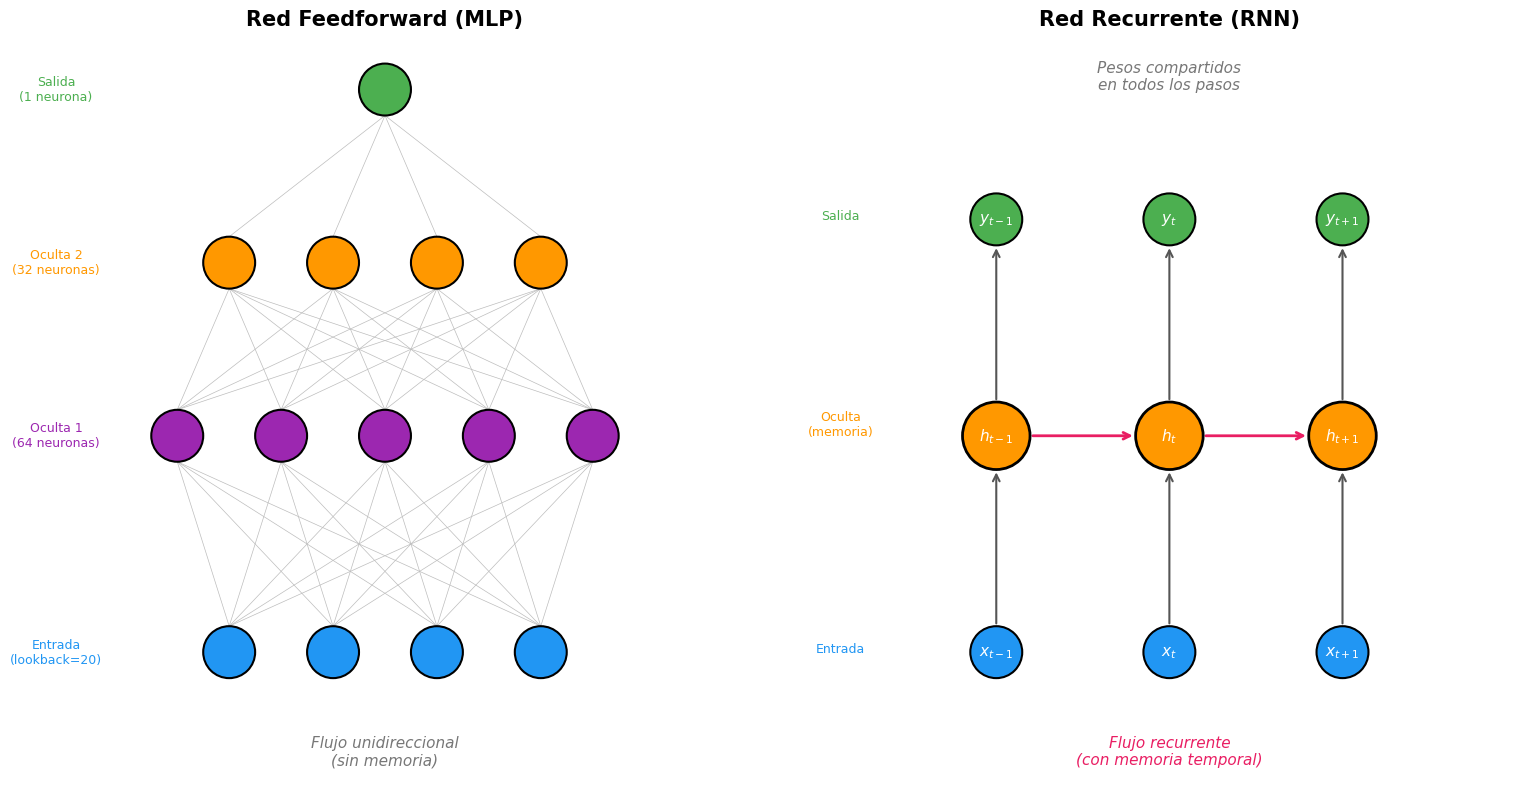

Figura guardada: fig7_comparacion_arquitecturas.png


In [12]:
def draw_architecture_comparison():
    """
    Diagrama comparativo: Feedforward vs RNN lado a lado.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    # Colores
    c_in = '#2196F3'
    c_h1 = '#9C27B0'
    c_h2 = '#FF9800'
    c_out = '#4CAF50'

    # ════ Panel Izquierdo: Feedforward ════
    ax1.set_xlim(-1, 7)
    ax1.set_ylim(-0.5, 8)
    ax1.set_aspect('equal')
    ax1.axis('off')
    ax1.set_title('Red Feedforward (MLP)', fontsize=15, fontweight='bold', pad=15)

    layers_ff = [
        {'y': 1, 'n': 4, 'color': c_in, 'label': 'Entrada\n(lookback=20)'},
        {'y': 3.5, 'n': 5, 'color': c_h1, 'label': 'Oculta 1\n(64 neuronas)'},
        {'y': 5.5, 'n': 4, 'color': c_h2, 'label': 'Oculta 2\n(32 neuronas)'},
        {'y': 7.5, 'n': 1, 'color': c_out, 'label': 'Salida\n(1 neurona)'},
    ]

    r = 0.3
    all_positions = []

    for layer in layers_ff:
        n = layer['n']
        y = layer['y']
        color = layer['color']
        positions = []
        total_width = (n - 1) * 1.2
        start_x = 3 - total_width / 2

        for i in range(n):
            cx = start_x + i * 1.2
            circle = plt.Circle((cx, y), r, color=color, ec='black', lw=1.5, zorder=5)
            ax1.add_patch(circle)
            positions.append((cx, y))

        ax1.text(-0.8, y, layer['label'], ha='center', va='center', fontsize=9, color=color)
        all_positions.append(positions)

    # Conexiones entre capas
    for l in range(len(all_positions) - 1):
        for (x1, y1) in all_positions[l]:
            for (x2, y2) in all_positions[l + 1]:
                ax1.plot([x1, x2], [y1 + r, y2 - r], color='#BDBDBD', lw=0.5, zorder=1)

    ax1.text(3, -0.3, 'Flujo unidireccional\n(sin memoria)', ha='center',
            fontsize=11, fontstyle='italic', color='#777')

    # ════ Panel Derecho: RNN ════
    ax2.set_xlim(-1, 7)
    ax2.set_ylim(-0.5, 8)
    ax2.set_aspect('equal')
    ax2.axis('off')
    ax2.set_title('Red Recurrente (RNN)', fontsize=15, fontweight='bold', pad=15)

    # 3 pasos temporales
    steps = 3
    spacing = 2.0
    labels = ['t-1', 't', 't+1']

    for i in range(steps):
        cx = 1 + i * spacing

        # Entrada
        inp = plt.Circle((cx, 1), r, color=c_in, ec='black', lw=1.5, zorder=5)
        ax2.add_patch(inp)
        ax2.text(cx, 1, f'$x_{{{labels[i]}}}$', ha='center', va='center',
                fontsize=11, color='white', fontweight='bold', zorder=6)

        # Oculta
        hid = plt.Circle((cx, 3.5), r * 1.3, color=c_h2, ec='black', lw=2, zorder=5)
        ax2.add_patch(hid)
        ax2.text(cx, 3.5, f'$h_{{{labels[i]}}}$', ha='center', va='center',
                fontsize=11, color='white', fontweight='bold', zorder=6)

        # Salida
        out = plt.Circle((cx, 6), r, color=c_out, ec='black', lw=1.5, zorder=5)
        ax2.add_patch(out)
        ax2.text(cx, 6, f'$y_{{{labels[i]}}}$', ha='center', va='center',
                fontsize=11, color='white', fontweight='bold', zorder=6)

        # Flecha: Entrada -> Oculta
        ax2.annotate('', xy=(cx, 3.5 - r * 1.3), xytext=(cx, 1 + r),
                    arrowprops=dict(arrowstyle='->', lw=1.5, color='#555'))

        # Flecha: Oculta -> Salida
        ax2.annotate('', xy=(cx, 6 - r), xytext=(cx, 3.5 + r * 1.3),
                    arrowprops=dict(arrowstyle='->', lw=1.5, color='#555'))

        # Flechas recurrentes
        if i < steps - 1:
            cx_next = cx + spacing
            ax2.annotate('', xy=(cx_next - r * 1.3, 3.5),
                        xytext=(cx + r * 1.3, 3.5),
                        arrowprops=dict(arrowstyle='->', lw=2, color='#E91E63'))

    ax2.text(-0.8, 1, 'Entrada', ha='center', fontsize=9, color=c_in)
    ax2.text(-0.8, 3.5, 'Oculta\n(memoria)', ha='center', fontsize=9, color=c_h2)
    ax2.text(-0.8, 6, 'Salida', ha='center', fontsize=9, color=c_out)
    ax2.text(3, 7.5, 'Pesos compartidos\nen todos los pasos', ha='center',
            fontsize=11, fontstyle='italic', color='#777')
    ax2.text(3, -0.3, 'Flujo recurrente\n(con memoria temporal)', ha='center',
            fontsize=11, fontstyle='italic', color='#E91E63')

    plt.tight_layout()
    plt.savefig('fig7_comparacion_arquitecturas.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print('Figura guardada: fig7_comparacion_arquitecturas.png')

draw_architecture_comparison()

## 9. Resumen de Resultados

### Tabla Comparativa

In [13]:
print('\n' + '='*70)
print('          RESUMEN COMPARATIVO: FEEDFORWARD vs. RNN')
print('='*70)
print(f'\nParámetros MLP:  {total_params_mlp:>6,}')
print(f'Parámetros RNN:  {total_params_rnn:>6,}')
print(f'\nMSE Final (test) - MLP:  {mlp_test_losses[-1]:.6f}')
print(f'MSE Final (test) - RNN:  {rnn_test_losses[-1]:.6f}')
print(f'\nMAE - MLP:  {mlp_mae:.6f}')
print(f'MAE - RNN:  {rnn_mae:.6f}')

if rnn_mse < mlp_mse:
    mejora = ((mlp_mse - rnn_mse) / mlp_mse) * 100
    print(f'\n✅ La RNN supera al MLP con una reducción del {mejora:.1f}% en MSE.')
else:
    mejora = ((rnn_mse - mlp_mse) / rnn_mse) * 100
    print(f'\n⚠️ El MLP supera a la RNN en esta configuración (diferencia: {mejora:.1f}% MSE).')
    print('   Esto puede ocurrir con señales simples donde la ventana deslizante')
    print('   captura suficiente contexto para el MLP.')

print('\n' + '='*70)
print('Figuras generadas para incluir en el informe Word:')
print('  • fig1_arquitectura_rnn.png        → Sección 2.2 (Diseño RNN Simple)')
print('  • fig2_serie_tiempo.png             → Sección 2.3 (Ejemplo Práctico)')
print('  • fig3_curvas_perdida.png           → Sección 2.3 (Resultados)')
print('  • fig4_predicciones_comparativas.png → Sección 2.3 (Predicciones)')
print('  • fig5_metricas_comparativas.png    → Sección 2.3 (Métricas)')
print('  • fig6_flujo_datos_rnn.png          → Sección 2.3 (Flujo de datos)')
print('  • fig7_comparacion_arquitecturas.png → Sección 2.1 (Comparación)')
print('='*70)


          RESUMEN COMPARATIVO: FEEDFORWARD vs. RNN

Parámetros MLP:   3,457
Parámetros RNN:   1,153

MSE Final (test) - MLP:  0.003065
MSE Final (test) - RNN:  0.002777

MAE - MLP:  0.045381
MAE - RNN:  0.042841

✅ La RNN supera al MLP con una reducción del 9.4% en MSE.

Figuras generadas para incluir en el informe Word:
  • fig1_arquitectura_rnn.png        → Sección 2.2 (Diseño RNN Simple)
  • fig2_serie_tiempo.png             → Sección 2.3 (Ejemplo Práctico)
  • fig3_curvas_perdida.png           → Sección 2.3 (Resultados)
  • fig4_predicciones_comparativas.png → Sección 2.3 (Predicciones)
  • fig5_metricas_comparativas.png    → Sección 2.3 (Métricas)
  • fig6_flujo_datos_rnn.png          → Sección 2.3 (Flujo de datos)
  • fig7_comparacion_arquitecturas.png → Sección 2.1 (Comparación)
